# Laboratorio 5
In questo laboratorio costruiremo un sistema RAG completo utilizzando il dataset MaartenGr/arxiv_nlp di Hugging Face, che contiene abstract di articoli NLP da arXiv.
L’obiettivo è creare un assistente che possa rispondere a domande sulla letteratura scientifica in NLP, citando le fonti.
## 1. Installazione librerie necessarie
- datasets: per caricare il dataset da Hugging Face
- sentence-transformers: per generare embeddings semantici
- faiss: vector database per retrieval efficiente
- transformers: per il modello generativo locale
- torch: backend per i modelli
- rank_bm25: per il retrieval lessicale BM25
- matplotlib: per visualizzare le distribuzioni delle similarità

In [ ]:
%pip install datasets transformers sentence-transformers faiss-cpu torch accelerate matplotlib rank_bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 53.5 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import faiss

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch: 2.11.0+cu128
Device: CUDA


## 2. Caricamento Dataset
Importazione delle risorse da arXiv

In [ ]:
print("Caricamento dataset arXiv NLP...")
dataset = load_dataset("MaartenGr/arxiv_nlp", split="train")
df = pd.DataFrame(dataset)

print(f"Documenti caricati: {len(df)}")
print(f"Colonne: {df.columns.tolist()}")
df.head(2)

Caricamento dataset arXiv NLP...


README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/53.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44949 [00:00<?, ? examples/s]

Documenti caricati: 44949
Colonne: ['Titles', 'Abstracts', 'Years', 'Categories']


,Titles,Abstracts,Years,Categories
0,Introduction to Arabic Speech Recognition Usin...,In this paper Arabic was investigated from t...,2007,Computation and Language
1,Arabic Speech Recognition System using CMU-Sph...,In this paper we present the creation of an ...,2007,Computation and Language


In [ ]:
# Prepara documenti
documents = []
metadata = []

# Auto-rileva colonne (gestisce varianti del dataset)
title_col = next((c for c in df.columns if 'title' in c.lower()), df.columns[0])
abstract_col = next((c for c in df.columns if 'abstract' in c.lower() or 'summar' in c.lower()), df.columns[1])

print(f"Colonna titolo: {title_col}")
print(f"Colonna abstract: {abstract_col}\n")

# Riempimento delle strutture dati con i dati rilevati dal dataset
# Combiniamo titolo e abstract perché sono semanticamente coesi
for idx, row in df.iterrows():
    title = str(row[title_col]) if pd.notna(row[title_col]) else 'No Title'
    abstract = str(row[abstract_col]) if pd.notna(row[abstract_col]) else 'No Abstract'

    documents.append(f"Title: {title}\n\nAbstract: {abstract}")
    metadata.append({
        'title': title,
        'year': str(row.get('year', 'Unknown'))
    })

print(f"Documenti preparati: {len(documents)}")
print(f"\nEsempio:\n{documents[0][:300]}...")

Colonna titolo: Titles
Colonna abstract: Abstracts

Documenti preparati: 44949

Esempio:
Title: Introduction to Arabic Speech Recognition Using CMUSphinx System

Abstract:   In this paper Arabic was investigated from the speech recognition problem
point of view. We propose a novel approach to build an Arabic Automated Speech
Recognition System (ASR). This system is based on the open sou...


## 3. Generazione Embeddings
Utilizziamo il modello `all-MiniLM-L6-v2` di Sentence Transformers per generare embeddings semantici dei documenti.

In [ ]:
print("Caricamento modello di embedding...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generazione embeddings...")
embeddings = embed_model.encode(
    documents,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"\nEmbeddings shape: {embeddings.shape}")

Caricamento modello di embedding...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generazione embeddings...


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]


Embeddings shape: (44949, 384)


## 4. Vector Store (FAISS)
Creiamo un indice FAISS per il retrieval efficiente dei documenti basato sugli embeddings generati. Utilizziamo un indice di tipo `IndexFlatIP`, che calcola il prodotto interno (Inner Product) tra i vettori, utile per misurare la similarità coseno. E' ottimale per le ricerche esatte nel dataset.

In [ ]:
# Crea indice FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print(f"Indice FAISS creato: {index.ntotal} vettori")

Indice FAISS creato: 44949 vettori


## 5. Retriever
Funzione di recupero dei documenti più rilevanti dato un input di query. La funzione `retrieve` prende una query testuale, la trasforma in embedding e cerca i k documenti più simili nell'indice FAISS.

In [ ]:
def retrieve(query, k=5):
    """Recupera i k documenti più rilevanti"""
    query_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    similarities, indices = index.search(query_emb, k)

    results = []
    for i, (sim, idx) in enumerate(zip(similarities[0], indices[0])):
        results.append({
            'rank': i + 1,
            'doc_id': int(idx),
            'similarity': float(sim),
            'document': documents[idx],
            'metadata': metadata[idx]
        })
    return results

# Test retrieval
test_query = "What are transformer models?"
results = retrieve(test_query, k=3)

print(f"Query: {test_query}\n")
for r in results:
    print(f"[{r['rank']}] Similarity: {r['similarity']:.3f}")
    print(f"    {r['metadata']['title'][:80]}")
    print()

Query: What are transformer models?

[1] Similarity: 0.679
    Transformer models: an introduction and catalog

[2] Similarity: 0.532
    CoTFormer: More Tokens With Attention Make Up For Less Depth

[3] Similarity: 0.499
    Neutron: An Implementation of the Transformer Translation Model and its
  Varian



## 6. Hybrid search
Utilizziamo un approccio ibrido combinando BM25 e FAISS.
BM25 è un modello di rappresetnazione dei documenti tramite vettori di frequenze: estende tf-idf tramite l'introduzione della saturazione (dopo a un certo punto, aumentare la frequenza non aumenta significativamente il peso).

La funzione `hybrid_retrieve` calcola i punteggi di entrambi i metodi, li normalizza e li fonde per ottenere un ranking finale. Per lo score di ranking viene utilizzata la formula:
$score(q,d) = \alpha \cdot BM25(q,d) + (1 - \alpha) \cdot similarity(q,d)$

$\alpha$ è un paramentro che bilancia le due parti ed è un valore compreso tra 0 e 1.

Il processo si articola in più fasi:
- Si calcolano singolarmente i punteggi di BM25 (lessicale) e di FAIIS (semantico) per tutti i documenti
- Si riordinano i punteggi di FAIIS in modo da essere compatibile con BM25, il quale restituisce i punteggi con gli indici ordinati
- Si normalizzano i due punteggi tramite la funzione normalize(); di solito i punteggi di di BM25 prevalgono su quelli di FAIIS, dunque è un operazione che serve a renderli confontabili, evitando uno squilibrio
- Si calcola lo score di ranking e si stampano i primi risultati.

In [ ]:
from rank_bm25 import BM25Okapi

# Tokenizzazione in words dei documenti
tokenized_corpus = [doc.split(" ") for doc in documents]
bm25 = BM25Okapi(tokenized_corpus)

# Funzione di normalizzazione
def normalize(scores):
    scores = np.array(scores)
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

# Funzione di Hybrid Search dei primi k risultati
def hybrid_retrieve(query, k=5, alpha=0.5):
    """ Recupera i k documenti più rilevanti combinando BM25 e FAISS. """
    # Puntaggio BM250
    tokenized_query = query.split(" ")
    bm25_scores = bm25.get_scores(tokenized_query)

    # Punteggio FAISS
    embedded_query = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    faiss_scores, faiss_indices = index.search(embedded_query, len(documents))

    # Riordinamento dei punteggi FAISS per allinearli con BM25
    sim_full = np.zeros(len(documents))
    for sim, idx in zip(faiss_scores[0], faiss_indices[0]):
        sim_full[idx] = sim

    # Normalizzazione
    bm25_scores_normalized = normalize(bm25_scores)
    faiss_scores_normalized = normalize(sim_full)

    # Calcolo punteggio di ranking
    score = alpha * bm25_scores_normalized + (1 - alpha) * faiss_scores_normalized
    top_k_idx = np.argsort(score)[::-1][:k]

    # Stampa dei risultati
    results = []
    for rank, doc_idx in enumerate(top_k_idx):
        results.append({
            'rank': rank + 1,
            'doc_id': int(doc_idx),
            'score': float(score[doc_idx]),
            'document': documents[doc_idx],
            'metadata': metadata[doc_idx]
        })
    return results

## 7. Re-ranking
La funzione `reranking()` è stata creata per scegliere, tra i risultati ottenuti dall'hybrid search, i risultati più rilevanti.
Vengono passati i risultati dell'hybrid search con la variabile `risultati_hybrid`.

Si usa `CrossEncoder` come modello di reranking, per calcolare il punteggio di rerank tra query e ogni documento. Questo indica l'affinità tra i due. I risultati vengono ordinati in base al punteggio di rerank e ne vengono restituiti solo i primi k.

In [ ]:
from sentence_transformers import CrossEncoder
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def reranking(query, risultati_hybrid, top_k=5):
    """ Funzione di re-ranking dei risultati dell'hybrid search """
    # Crea la coppia query-documento per ogni risultato dell'hybrid search
    coppie_query_documents = [(query, risultati["document"]) for risultati in risultati_hybrid]

    # Restituisce un array di coppie di punteggi per ogni coppia query-documento
    # Li assegniamo a ogni coppia corrispondente
    risultati_rerank = reranker.predict(coppie_query_documents)
    for c, score in zip(risultati_hybrid, risultati_rerank):
        c['cross_score'] = float(score)

    # Riordiniamo i risultati
    reranked = sorted(risultati_hybrid, key=lambda x: x['cross_score'], reverse=True)[:top_k]

    # Assegniamo la posizione al campo rank del risultato
    for i, r in enumerate(reranked):
        r['rank'] = i + 1

    return reranked

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

## 8. Test set e Precision@k
Creiamo un test set e valutiamo l'accuratezza di un sistema RAG di rilevare k documenti che siano pertinenti con la query con la misura Precision@k. La formula è la seguente:
$\frac{\text{Elementi Rilevanti nei primi } k}{k}$

Per la creazione del test set, si è deciso di usare un criterio basato sulla presenza di una parola chiave nei documenti con la funzione `relevance()`. Se la parola chiave è presente in un documento, allora quel documento è considerato rilevante per la query corrispondente.

Iterando sul test set, si recuperano i risultati di retrieval, hybrid search e re-ranking per ogni query. La precision viene calcolata per ciascun metodo e stampata a video.

Nella variabile p la precision restituisce i 5 documenti che sono più affini alla query, quindi applicando la formula:
doc rilevanti dei primi k risultati/k -> rilevanti trovati / 5

In [ ]:
def precision(results, relevant_ids, k=5):
    """ Calcola la precision@k per un insieme di risultati. """
    top_k = results[:k]

    relevant_retrieved = 0
    for r in top_k:
        if r['doc_id'] in relevant_ids:
            relevant_retrieved += 1

    return relevant_retrieved / k

def relevance(keyword):
    """ Determina i documenti rilevanti ottenuti in base a una parola chiave. """
    relevant = set()
    for i, doc in enumerate(documents):
        if keyword.lower() in doc.lower():
            relevant.add(i)
    return relevant

# Creazione del test set con coppie query-documenti_rilevanti per quella query
test_set = {
    "Explain the attention mechanism in transformer": relevance("attention"),
    "Could you explain what a Generative Pre-trained Transformer is": relevance("GPT"),
    "What is a speech recognition task?": relevance("speech recognition"),
    "What is a gold standard?": relevance("gold standard"),
    "Could you explain why a treebank is": relevance("tree bank")
}

# Testing della ricerca
for query, relevant_ids in test_set.items():
    risultati_retrieve = retrieve(query, k=200)
    risultati_hybrid = hybrid_retrieve(query, k=200, alpha=0.5)
    risultati_reranking = reranking(query, risultati_hybrid, top_k=100)

    # Gestiamo l'assenza di documenti rilevanti
    if len(relevant_ids) == 0:
        print(f" Documenti rilevanti non disponibili per la query:  {query}\n")
        break

    p_retrieve = precision(risultati_retrieve, relevant_ids, k=90)
    p_hybrid = precision(risultati_hybrid, relevant_ids, k=90)
    p_reranking = precision(risultati_reranking, relevant_ids, k=90)

    # Stampiamo i risultati ottenuti
    print(f"Query: {query}")
    print(f"\tNumero di doc rilevanti: {len(relevant_ids)}")
    print(f"\tPrecision@k retrieve: {p_retrieve:.2f}")
    print(f"\tPrecision@k hybrid search: {p_hybrid:.2f}")
    print(f"\tPrecision@k re-ranking: {p_reranking:.2f}\n")

 Query: Explain the attention mechanism in transformer
  Numero di doc rilevanti nel ground truth: 5075
  Precision@k retrieve: 0.97
  Precision@k hybrid search: 0.97
  Precision@k re-ranking: 1.00

 Query: Could you explain what a Generative Pre-trained Transformer is
  Numero di doc rilevanti nel ground truth: 3358
  Precision@k retrieve: 0.30
  Precision@k hybrid search: 0.40
  Precision@k re-ranking: 0.70

 Query: What is a speech recognition task?
  Numero di doc rilevanti nel ground truth: 1504
  Precision@k retrieve: 0.63
  Precision@k hybrid search: 0.87
  Precision@k re-ranking: 0.90

 Query: What is a gold standard?
  Numero di doc rilevanti nel ground truth: 192
  Precision@k retrieve: 0.23
  Precision@k hybrid search: 0.40
  Precision@k re-ranking: 0.87

 Query: Could you explain whay a treebank is
  Numero di doc rilevanti nel ground truth: 44949
  Precision@k retrieve: 1.00
  Precision@k hybrid search: 1.00
  Precision@k re-ranking: 1.00



## 8. LLM Local
Utilizziamo un modello LLM locale per generare risposte basate sui documenti recuperati.
In questo caso, scegliamo il modello Phi2 al posto di Qwen3-4B-Instruct-2507.

In [ ]:
model_id = "Qwen/Qwen3-4B-Instruct-2507"
#cambiato modello da Qwen/Qwen2.5-0.5B-Instruct a microsoft/phi-2, venkycs/phi-2-instruct, Qwen/Qwen3-4B-Instruct-2507
model_phi = "microsoft/phi-2"

print(f"Caricamento {model_phi}...")

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_phi)
model = AutoModelForCausalLM.from_pretrained(
    model_phi,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    low_cpu_mem_usage=True
)

llm = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    device=0 if device == "cuda" else -1,
    max_new_tokens=300,
)

print(f"Modello caricato su {device}")

Caricamento Qwen/Qwen3-4B-Instruct-2507...
Download: ~500MB, tempo: ~1-2 minuti



config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Modello caricato su cuda


## 9. Sistema RAG Completo
Implementazione del sistema rag completo con hybrid search e reranking. La funzione `rag_answer()` prende in input una query, recupera i documenti più rilevanti, costruisce un contesto e genera una risposta basata su di esso.

In [ ]:
def rag_answer(query, k=5, verbose=True, temperature = 0.7):
    """Risponde alla query usando RAG system"""

    if verbose:
        print(f"Query: {query}\n")
        print("=" * 60)
        print("RETRIEVAL")
        print("=" * 60)

    # 1. Retrieval
    hybrid_results = hybrid_retrieve(query, k=k*2)
    results = reranking(query, hybrid_results, top_k=k)

    if verbose:
        for r in results:
            print(f"[{r['rank']}] {r['metadata']['title'][:70]}")
            print(f"\tSimilarity: {r['cross_score']:.3f}")

    # 2. Costruisci contesto
    context_parts = []
    for r in results:
        context_parts.append(f"[Document {r['rank']}]\n{r['document']}")
    context = "\n\n".join(context_parts)

    # Limita contesto per modelli piccoli
    if len(context) > 1500:
        context = context[:1500] + "\n[...truncated...]"

    # 3. Costruisci prompt
    # Settiamo il template utilizzato da phi2
    # Il template specifico per Phi-2 gestisce system, user e inserisce Instruct/Output
    phi2_template = (
        "{% for message in messages %}"
            "{% if message['role'] == 'system' %}"
                "Instruct: Contesto di sistema: {{ message['content'] }}\n"
            "{% elif message['role'] == 'user' %}"
                "{% if not loop.first and messages[loop.index0 - 1]['role'] != 'system' %}Instruct: {% endif %}"
                "{{ message['content'] }}\nOutput:"
            "{% elif message['role'] == 'assistant' %}"
                "{{ message['content'] }}\n"
            "{% endif %}"
        "{% endfor %}"
    )
    tokenizer.chat_template = phi2_template

    # Template per messaggio
    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant specialized in NLP research. Answer based on the provided context."
        },
        {
            "role": "user",
            "content": f"""Context from research papers: {context}\n\n
            Question: {query}\n\n
            Answer based on the context above:"""
        }
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # 4. Genera risposta
    if verbose:
        print("\n" + "=" * 60)
        print("GENERATION")
        print("=" * 60)

    output = llm(
        prompt,
        max_new_tokens=250,
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )

    # Estrai risposta
    full_text = output[0]['generated_text']
    answer = full_text[len(prompt):].strip() if full_text.startswith(prompt) else full_text

    if verbose:
        print("\n" + "=" * 60)
        print("ANSWER")
        print("=" * 60)
        print(answer)
        print("\n" + "=" * 60)
        print("SOURCES")
        print("=" * 60)
        for r in results:
            print(f"- {r['metadata']['title']} ({r['metadata']['year']})")

    return {
        'query': query,
        'answer': answer,
        'sources': results
    }

## 10. Test del Sistema
Testiamo il sistema completo variando temperature e k per osservare come cambia la generazione della risposta. Utilizziamo le tre query proposte.

In [ ]:
temps=[0.1, 0.3, 0.6, 0.9]
ks = [3, 5, 10]
queries = [
    "What is BERT and how does it work?",
    "Explain the attention mechanism in transformers",
    "What are the main differences between BERT and GPT?"
]

for query in queries:
    print(f"Query: {query}\n")
    for tem in temps:
        for k in ks:
            print(f"\tTemperature: {tem} e K: {k}\n")
            ris = rag_answer(query, k=k, temperature = tem)
            print(f"\tRisposta: {ris["answer"]}")

Query: What is BERT and how does it work?

RETRIEVAL


[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'top_p', 'do_sample', 'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] A Primer in BERTology: What we know about how BERT works
[2] What does BERT learn about prosody?
[3] What the [MASK]? Making Sense of Language-Specific BERT Models

GENERATION


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



ANSWER
Based on the provided context, BERT (Bidirectional Encoder Representations from Transformers) is a transformer-based model that has achieved state-of-the-art results in many areas of natural language processing (NLP). It works by learning generalized representations of language through training on large amounts of text data, without predefined linguistic targets. Instead, it learns implicit representations of linguistic information, including structural elements like prosody, through bidirectional context understanding. The model's success stems from its ability to capture rich, contextualized representations of language, which are then used in various NLP tasks. However, the exact mechanisms behind its success and the specific nature of the information it learns are still not fully understood, and ongoing research explores its representational capacity, training objectives, architecture, and interpretability.

SOURCES
- A Primer in BERTology: What we know about how BERT works 

...

[1] A Primer in BERTology: What we know about how BERT works
[2] What does BERT learn about prosody?
[3] What the [MASK]? Making Sense of Language-Specific BERT Models

GENERATION

ANSWER
Based on the provided context, BERT (Bidirectional Encoder Representations from Transformers) is a transformer-based model that has achieved state-of-the-art performance in many natural language processing (NLP) tasks. It works by learning generalized representations of language through training on vast amounts of text data, without predefined linguistic targets. Instead, BERT learns implicit representations of linguistic information, including structural elements like prosody, through bidirectional context understanding—meaning it considers both the words before and after a given word when processing text.

The model's success stems from its ability to capture rich, contextual information, which is then used to perform various NLP tasks. However, the exact mechanisms behind its performance and the na

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] A Primer in BERTology: What we know about how BERT works
[2] What does BERT learn about prosody?
[3] What the [MASK]? Making Sense of Language-Specific BERT Models

GENERATION

ANSWER
Based on the provided context, BERT (Bidirectional Encoder Representations from Transformers) is a transformer-based model that has achieved state-of-the-art results in many areas of natural language processing (NLP). It works by learning generalized representations of language through a training process that does not define predetermined linguistic targets. Instead, BERT learns implicit representations of language by processing text bidirectionally, allowing it to understand context from both the left and right sides of a word. This enables BERT to capture rich linguistic information, including structural elements like prosody, which may be part of the language's representation. However, the exact internal mechanisms and representations behind its success are still not fully understood, and ongoing r

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] A Primer in BERTology: What we know about how BERT works
[2] What does BERT learn about prosody?
[3] What the [MASK]? Making Sense of Language-Specific BERT Models

GENERATION

ANSWER
Based on the provided context, BERT (Bidirectional Encoder Representations from Transformers) is a transformer-based model that has achieved state-of-the-art performance in many natural language processing (NLP) tasks. It works by learning generalized representations of language through training on large corpora without predefined linguistic targets. Instead, it captures implicit linguistic information, including structural aspects like prosody, by processing input text in a bidirectional manner—meaning it considers both the context before and after each word. This allows BERT to understand the meaning of words based on their surrounding context, enabling it to represent complex linguistic features. However, while BERT's performance is impressive, the exact mechanisms behind its success and the specif

I risultati mostrano come la temperatura influenzi la creatività e la variabilità delle risposte generate dal modello. Temperature più basse tendono a produrre risposte più conservative e coerenti, mentre temperature più alte possono generare risposte più varie e creative, ma talvolta meno precise.
Allo stesso modo, aumentando il numero di documenti recuperati (k), il modello ha accesso a un contesto più ampio, che può migliorare la qualità della risposta, ma può anche introdurre informazioni meno rilevanti se k è troppo grande.

## 11. Analisi Retrieval
Analizziamo la distribuzione delle similarità dei documenti recuperati per una query specifica. Questo ci permette di capire come i documenti si distribuiscono in termini di rilevanza rispetto alla query.

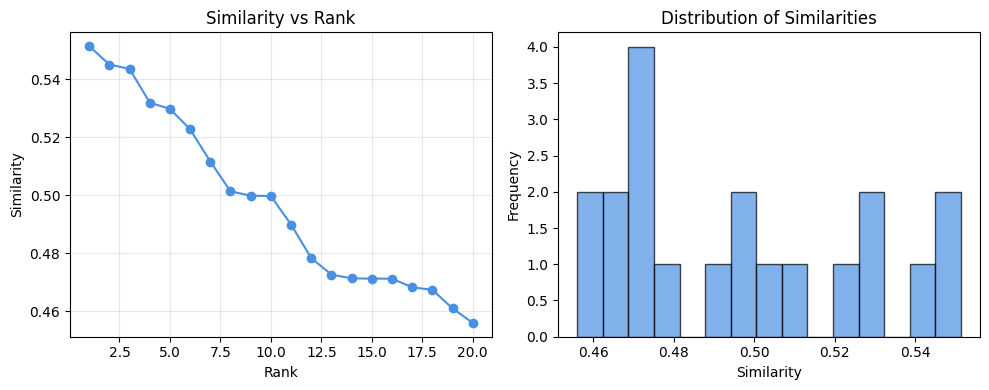

Query: What are neural networks?
Mean similarity: 0.497
Std similarity: 0.030


In [ ]:
# Query di riferimento
query = "What are neural networks?"
results_retrieve = retrieve(query, k=20)
results_hybrid = hybrid_retrieve(query, k=20)
results_reranking = reranking(query, results_retrieve, top_k=15)

# Similarità di ogni risultato
similarities_retrieve = [r['similarity'] for r in results_retrieve]
similarities_hybrid = [r['similarity'] for r in results_hybrid]
similarities_reranking = [r['similarity'] for r in results_reranking]

# Rank di rilevanza
ranks_retrieve = [r['rank'] for r in results_retrieve]
ranks_hybrid = [r['rank'] for r in results_hybrid]
ranks_reranking = [r['rank'] for r in results_reranking]

In [ ]:
import matplotlib.pyplot as plt

def graph(ranks, similarities):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(ranks, similarities, 'o-', color='#4A90E2', label='Retrieve')
    plt.xlabel('Rank')
    plt.ylabel('Similarity')
    plt.title('Similarity vs Rank')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(similarities, bins=15, color='#4A90E2', alpha=0.7, edgecolor='black')
    plt.xlabel('Similarity')
    plt.ylabel('Frequency')
    plt.title('Distribution of Similarities')

    plt.tight_layout()
    plt.show()

    print(f"Query: {query}")
    print(f"Mean similarity: {np.mean(similarities):.3f}")
    print(f"Std similarity: {np.std(similarities):.3f}")

graph(ranks_retrieve, similarities_retrieve)
graph(ranks_hybrid, similarities_hybrid)
graph(ranks_reranking, similarities_reranking)